In [ ]:
!pip install 

In [1]:
#####---plot Gleam_data for Evaporationtranspiration--#########
from pathlib import Path
import pandas as pd
import xarray as xr
import h5netcdf
import netCDF4
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
#Python package for calculating reference crop evapotranspiration (ETo)=potential evapotranspiration (PET)
import eto
from mpl_toolkits.basemap import Basemap
from landlab import RasterModelGrid
from landlab.components.pet import PotentialEvapotranspiration
from datetime import datetime
from netCDF4 import Dataset as NetCDFFile
from mpl_toolkits.basemap import addcyclic
# importing numpy as geek 
# and numpy.ma module as ma
import numpy as geek
import numpy.ma as ma
# Requires the pyshp package
import shapefile
import time
import os
import regionmask
import geopandas as gpd
import shapefile as shp
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from matplotlib.collections import LineCollection
from matplotlib.collections import PolyCollection
from matplotlib.colors import Normalize

from netCDF4 import Dataset
import h5py

C:\Users\Fatima\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


In [5]:
#read file
my_example_nc_file = 'C:\\Users\\Fatima\\Desktop\\nc_file\\EO_project\\oout_file.nc'
fh = Dataset(my_example_nc_file, mode='r')
print(type(fh)) # print the type of the data 
print(fh.variables.keys()) # print the variables in the data

<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:2: SyntaxWarning: invalid escape sequence '\A'
C:\Users\Fatima\AppData\Local\Temp\ipykernel_5204\1717669440.py:2: SyntaxWarning: invalid escape sequence '\A'
  my_example_nc_file ='This PC\A24 الخاص بـ فاطمة\Internal storage\Documents\oout_file.nc'
C:\Users\Fatima\AppData\Local\Temp\ipykernel_5204\1717669440.py:2: SyntaxWarning: invalid escape sequence '\A'
  my_example_nc_file ='This PC\A24 الخاص بـ فاطمة\Internal storage\Documents\oout_file.nc'


FileNotFoundError: [Errno 2] No such file or directory: 'This PC\\A24 الخاص بـ فاطمة\\Internal storage\\Documents\\oout_file.nc'

In [3]:
fh

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): time(12), lon(3600), lat(1800)
    variables(dimensions): int64 time(time), float64 lon(lon), float64 lat(lat), float32 Ep(time, lat, lon)
    groups: 

In [4]:
#EP.data

In [5]:
#EP.data.shape

In [6]:
fh.variables['Ep'].mask

True

In [25]:
# we have read the data from any of the variables contained in ‘data’
lat = fh.variables['lat'][:]
lon = fh.variables['lon'][:]
time = fh.variables['time'][:]
EP = fh.variables['Ep'][:]
print("latitude =" ,lat)
print("longitude = ",lon)
print("time = ",time)
print("EP = ",EP)
EP

latitude = [ 89.95  89.85  89.75 ... -89.75 -89.85 -89.95]
longitude =  [-179.95 -179.85 -179.75 ...  179.75  179.85  179.95]
time =  [  0  28  59  89 120 150 181 212 242 273 303 334]
EP =  [[[-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  ...
  [-- -- 1.501190423965454 ... 1.5006731748580933 1.500617504119873 --]
  [-- -- 1.5156145095825195 ... 1.5146952867507935 1.5147799253463745 --]
  [-- -- 1.518520712852478 ... 1.5182678699493408 1.5182876586914062 --]]

 [[-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  ...
  [-- -- 0.4368084967136383 ... 0.4366024136543274 0.4368182122707367 --]
  [-- -- 0.43986934423446655 ... 0.43951529264450073 0.4394892156124115
   --]
  [-- -- 0.45678800344467163 ... 0.4568062722682953 0.45680224895477295
   --]]

 [[-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  ...
  [-- -- 0.31506115198135376 ... 0.3148854672908783 0.31487950682640076
   --]
  [-- -- 0.3150371313095

masked_array(
  data=[[[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, 1.501190423965454, ..., 1.5006731748580933,
          1.500617504119873, --],
         [--, --, 1.5156145095825195, ..., 1.5146952867507935,
          1.5147799253463745, --],
         [--, --, 1.518520712852478, ..., 1.5182678699493408,
          1.5182876586914062, --]],

        [[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, 0.4368084967136383, ..., 0.4366024136543274,
          0.4368182122707367, --],
         [--, --, 0.43986934423446655, ..., 0.43951529264450073,
          0.4394892156124115, --],
         [--, --, 0.45678800344467163, ..., 0.4568062722682953,
          0.45680224895477295, --]],

        [[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
     

C:\Users\Fatima\AppData\Local\Temp\ipykernel_6424\3640236968.py:29: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = mp.colorbar(c_scheme,location='right',pad = '10%')


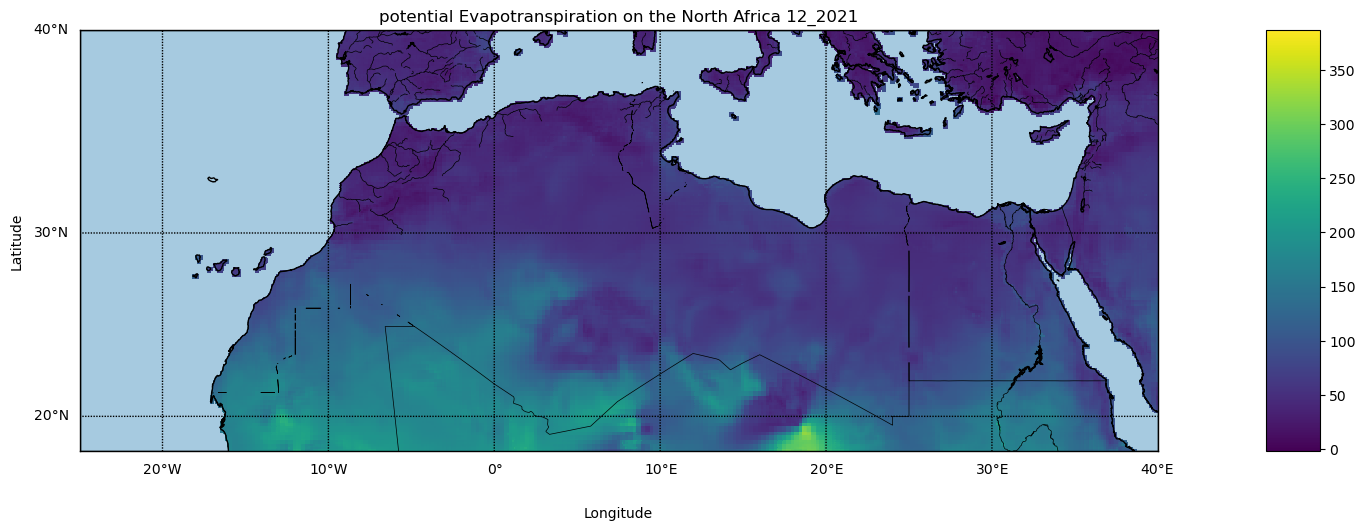

In [26]:
fig, ax=plt.subplots(figsize=(16,10))
#########
mp = Basemap(projection='merc',
             llcrnrlon=-25,   # lower longitude
             llcrnrlat=18,    # lower latitude
             urcrnrlon=40,   # uppper longitude
             urcrnrlat=40,   # uppper latitude
            resolution = 'i')
#reading shape file
mp.readshapefile('C:\\Users\\Fatima\\Desktop\\nc_file\\EO_project\\shape_file\\North_African_Arab_Countries', 
                 'C:\\Users\\Fatima\\Desktop\\nc_file\\EO_project\\shape_file\\North_African_Arab_Countries')

#this converts coordinates into 2D arrray
lon, lat = np.meshgrid(lon,lat)  
#mapping them together 
x,y = mp(lon,lat)

# [7,:,:] is for the first month of the year----------------
c_scheme = mp.pcolor(x,y,np.squeeze(EP[11,:,:])) 
mp.drawrivers()

# background color
mp.drawmapboundary(fill_color='#A6CAE0', color="black")
# consider this as the outline for the map that is to be created 
mp.drawcoastlines()
#mp.drawcountries()

# map information
cbar = mp.colorbar(c_scheme,location='right',pad = '10%') 
plt.title('potential Evapotranspiration on the North Africa 12_2021')
plt.xlabel('Longitude', labelpad=40)
plt.ylabel('Latitude', labelpad=40)
# Add Grid Lines
mp.drawparallels(np.arange(-80., 81., 10.), labels=[1,0,0,0], fontsize=10)
mp.drawmeridians(np.arange(-180., 181., 10.), labels=[0,0,0,1], fontsize=10)
#save plot
plt.savefig('C:\\Users\\Fatima\\Desktop\\nc_file\\EO_project\\EP_12_2021.jpg',dpi=300)
##

In [23]:
##############################################################

C:\Users\Fatima\AppData\Local\Temp\ipykernel_4932\3648182396.py:26: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = mp.colorbar(c_scheme,location='right',pad = '10%')


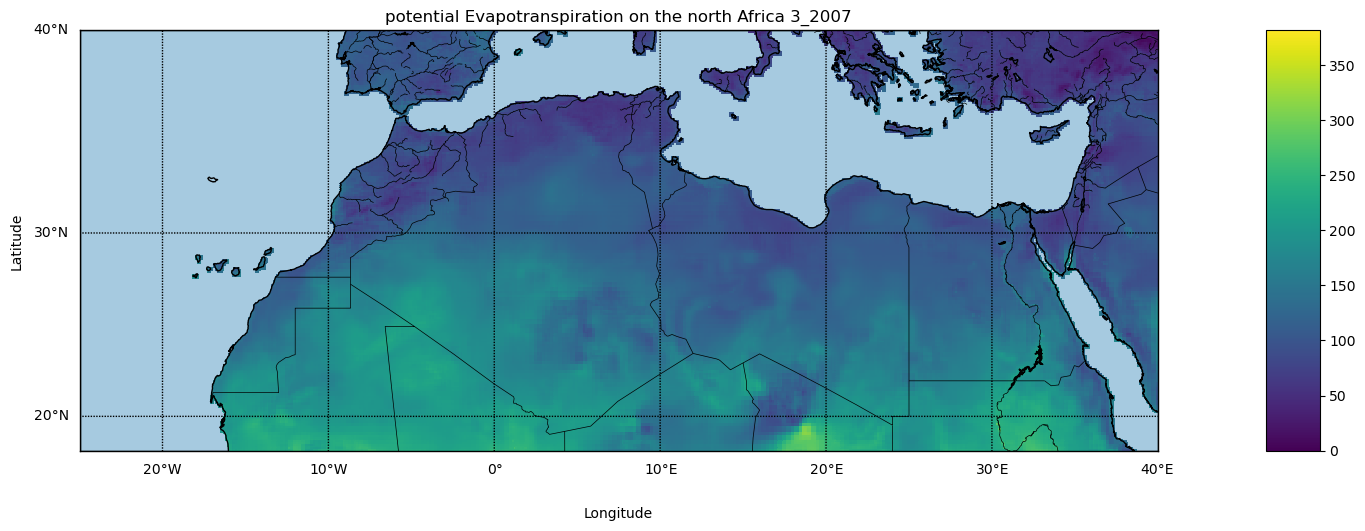

In [45]:
#without detect 20 lat in south Egypt#
mp = Basemap(projection='merc',
             llcrnrlon=-25,   # lower longitude
             llcrnrlat=18,    # lower latitude
             urcrnrlon=40,   # uppper longitude
             urcrnrlat=40,   # uppper latitude
            resolution = 'i')


#this converts coordinates into 2D arrray
lon, lat = np.meshgrid(lon,lat)  
x,y = mp(lon,lat) #mapping them together 
plt.figure(figsize=(16,10)) #figure size 
# [7,:,:] is for the first month of the year----------------
c_scheme = mp.pcolor(x,y,np.squeeze(EP[,:,:])) 
mp.drawrivers()
mp.bluemarble()
# background color
mp.drawmapboundary(fill_color='#A6CAE0', color="black")
# consider this as the outline for the map that is to be created 
mp.drawcoastlines()

#mp.drawcountries()
mp.drawstates(linewidth=0.5)

# map information
cbar = mp.colorbar(c_scheme,location='right',pad = '10%') 
plt.title('potential Evapotranspiration on the north Africa 4_2007')
plt.xlabel('Longitude', labelpad=40)
plt.ylabel('Latitude', labelpad=40)
# Add Grid Lines
mp.drawparallels(np.arange(-80., 81., 10.), labels=[1,0,0,0], fontsize=10)
mp.drawmeridians(np.arange(-180., 181., 10.), labels=[0,0,0,1], fontsize=10)

plt.savefig('C:\\Users\\Fatima\\Desktop\\nc_file\\EO_project\\EP_4_2007.jpg',dpi=300)
#plt.show()

In [50]:
# this will create 12 images in the path given 
# please set the path before executing 
lon, lat = np.meshgrid(lon,lat)
x,y = mp(lon,lat)
plt.figure(figsize=(16,10)) #figure size 

# loop for all the days 
months = np.arange(0,12)  # for considering all month of the year

for i in months:
    c_scheme = mp.pcolor(x,y,np.squeeze(EP[i,:,:]))
    mp.drawcoastlines()
    mp.drawstates()
    mp.drawcountries()

    cbar = mp.colorbar(c_scheme,location='right',pad = '10%')
    month = i+1
    
    plt.title('potential Evapotranspiration on the north Africa ' + str(month) +  ' of year 1980')
    plt.clim(-20,20)
    
    plt.savefig(r'C:\\Users\\Fatima\\Desktop\\nc_file\\EO_project\\GLEAM_data'+ '\\' + str(month)+'.jpg')
    plt.clf()

MemoryError: Unable to allocate 306. TiB for an array with shape (6480000, 6480000) and data type float64

In [ ]:
import PIL

image_frames = [] # creating a empty list to be appended later on
months = np.arange(1,12)

for k in months:
    new_fram = PIL.Image.open(r'C:\\Users\\Fatima\\Desktop\\nc_file\\EO_project\\GLEAM_data' + '\\' + str(k) + '.jpg') 
    image_frames.append(new_fram)

image_frames[0].save('EP_timelapse.gif',format='GIF',
                    append_images = image_frames[1: ],
                    save_all = True, duration = 12,
                    loop = 0)

In [13]:
"""
# we have read the data from any of the variables contained in ‘data’
lat = fh.variables['lat'][:]
lon = fh.variables['lon'][:]
time = fh.variables['time'][:]
EP = fh.variables['Ep'][:]
#EP,lon = addcyclic(EP,lon)
#map = Basemap(llcrnrlon=-80,llcrnrlat=80.,urcrnrlon=50.,urcrnrlat=80.,resolution='l')


mp = Basemap(projection='merc',
             llcrnrlon=8,   # lower longitude
             llcrnrlat=20,    # lower latitude
             urcrnrlon=35,   # uppper longitude
             urcrnrlat=50,   # uppper latitude
            resolution = 'i')


lons,lats = np.meshgrid(lon,lat)
x,y = map(lons,lats)
levels = np.arange(-19.5,20.0,0.5)
levels = levels[levels!=0]
ticks = np.arange(-20.0,20.0,4.0)
cs = map.contourf(x,y,EP[0],levels, cmap='bwr')
cbar = plt.colorbar(cs, orientation='horizontal', cmap='bwr', spacing='proportional', ticks=ticks)
cbar.set_label('Evapotranspiration')
map.drawcoastlines()
map.drawparallels(np.arange(-40,40,20),labels=[1,0,1,1], linewidth=0.5, fontsize=7)
map.drawmeridians(np.arange(0,360,40),labels=[1,1,0,1], linewidth=0.5, fontsize=7)
plt.show()



x,y = map(lons,lats)
levels = np.arange(-19.5,20.0,0.5)
levels = levels[levels!=0]
ticks = np.arange(-20.0,20.0,4.0)
cs = map.contourf(x,y,olr[0],levels, cmap='bwr')
cbar = plt.colorbar(cs, orientation='horizontal', cmap='bwr', spacing='proportional', ticks=ticks)
cbar.set_label('Outgoing Longwave Radiation Anomalies $\mathregular{(W/m^2)}$')
map.drawcoastlines()
map.drawparallels(np.arange(-40,40,20),labels=[1,0,1,1], linewidth=0.5, fontsize=7)
map.drawmeridians(np.arange(0,360,40),labels=[1,1,0,1], linewidth=0.5, fontsize=7)
"""

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Fatima\AppData\Local\Temp\ipykernel_9056\3126157950.py:1: SyntaxWarning: invalid escape sequence '\m'
  """


"\n# we have read the data from any of the variables contained in ‘data’\nlat = fh.variables['lat'][:]\nlon = fh.variables['lon'][:]\ntime = fh.variables['time'][:]\nEP = fh.variables['Ep'][:]\n#EP,lon = addcyclic(EP,lon)\n#map = Basemap(llcrnrlon=-80,llcrnrlat=80.,urcrnrlon=50.,urcrnrlat=80.,resolution='l')\n\n\nmp = Basemap(projection='merc',\n             llcrnrlon=8,   # lower longitude\n             llcrnrlat=20,    # lower latitude\n             urcrnrlon=35,   # uppper longitude\n             urcrnrlat=50,   # uppper latitude\n            resolution = 'i')\n\n\nlons,lats = np.meshgrid(lon,lat)\nx,y = map(lons,lats)\nlevels = np.arange(-19.5,20.0,0.5)\nlevels = levels[levels!=0]\nticks = np.arange(-20.0,20.0,4.0)\ncs = map.contourf(x,y,EP[0],levels, cmap='bwr')\ncbar = plt.colorbar(cs, orientation='horizontal', cmap='bwr', spacing='proportional', ticks=ticks)\ncbar.set_label('Evapotranspiration')\nmap.drawcoastlines()\nmap.drawparallels(np.arange(-40,40,20),labels=[1,0,1,1], line

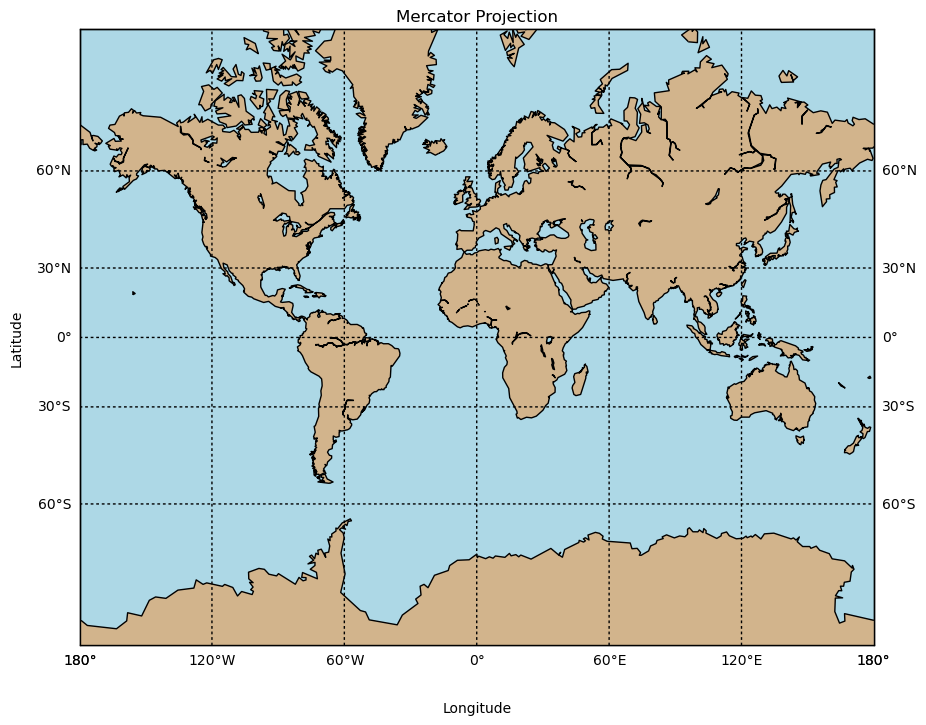

In [7]:
"""
#fig = plt.figure(num=None, figsize=(12, 8) )
#m = Basemap(projection='merc',llcrnrlat=-80,urcrnrlat=80,llcrnrlon=-180,urcrnrlon=180,resolution='c')
#m.drawcoastlines()
#plt.title("Mercator Projection")
#fig = plt.figure()

fig = plt.figure(num=None, figsize=(16, 8) )
m = Basemap(projection='merc',llcrnrlat=-80,urcrnrlat=80,llcrnrlon=-180,urcrnrlon=180,resolution='c')
m.drawcoastlines()
m.fillcontinents(color='tan',lake_color='lightblue')
# draw parallels and meridians.
m.drawparallels(np.arange(-90.,91.,30.),labels=[True,True,False,False],dashes=[2,2])
m.drawmeridians(np.arange(-180.,181.,60.),labels=[False,False,False,True],dashes=[2,2])
m.drawmapboundary(fill_color='lightblue')
plt.title("Mercator Projection")
plt.xlabel('Longitude', labelpad=40)
plt.ylabel('Latitude', labelpad=40)

#pet=fh.variables['Ep']
#plt.imshow(pet[0,:,:],cmap=plt.cm.get_cmap('jet'))
#plt.colorbar()

plt.show()
"""